# 🧱 Part 03: Embeddings and Position: Turning IDs Into Vectors

> **Previous context**: Parts 01-02 turned text into token IDs. Now the IDs need to become numbers a neural network can compute with.
> **Goal for this part**: Build Token Embedding and Position Encoding, then observe why both token identity and token order matter.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why IDs are not enough

A token ID is only a lookup number. The model needs a vector, because vectors can be added, multiplied, compared, and learned.

## 1. Token Embedding

An Embedding table is like a dictionary from token ID to vector. If token 5 means 'cat', row 5 of the table is the vector the model receives for that token.

## 2. Position information

Without position, 'dog bites man' and 'man bites dog' contain the same tokens. Position Encoding gives the model a way to know where each token sits.

## 3. Experiment

The code visualizes and compares token vectors and position vectors so you can see that the final input representation is token meaning plus location.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] Embedding maps token IDs to learnable vectors.
- [ ] Position Encoding tells the model token order.
- [ ] The model input is usually token embedding plus position information.

Next, continue through the code cells for the Foundation part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)
print(f"Read the values printed above and connect them to the concept in this cell.{torch.__version__}")

Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
ID=3  → "the"
ID=7  → "cat"
ID=12 → "mat"
```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

## 3. Embedding
### lookup
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell....
```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [2]:
# Teaching note: follow this line to see the main step.
vocab = ["the", "cat", "sat", "on", "mat", "dog", "log"]
vocab_size = len(vocab)
embed_dim = 4

embedding = nn.Embedding(vocab_size, embed_dim)

print(f"Vocabulary size: {vocab_size}Read the values printed above and connect them to the concept in this cell.{embed_dim}")
print(f"Read the values printed above and connect them to the concept in this cell.{embedding.weight.shape}Read the values printed above and connect them to the concept in this cell.{vocab_size}×{embed_dim}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{embedding.weight[:3]}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036]], grad_fn=<SliceBackward0>)


In [3]:
# Teaching note: follow this line to see the main step.
sentence_ids = torch.tensor([0, 1, 2, 3, 0, 4])  # "the cat sat on the mat"
vectors = embedding(sentence_ids)                  # Teaching note: follow this line to see the main step.

print(f"token IDs: {sentence_ids.tolist()}  →  {[vocab[i] for i in sentence_ids.tolist()]}")
print(f"Read the values printed above and connect them to the concept in this cell.{vectors.shape}  ← [{len(sentence_ids)}Read the values printed above and connect them to the concept in this cell.{embed_dim}Read the values printed above and connect them to the concept in this cell.")
print()

# Teaching note: follow this line to see the main step.
for i, (tid, vec) in enumerate(zip(sentence_ids.tolist(), vectors)):
    print(f"Read the values printed above and connect them to the concept in this cell.{i}: '{vocab[tid]}' (ID={tid}) → {vec.tolist()}")

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")

token IDs: [0, 1, 2, 3, 0, 4]  →  ['the', 'cat', 'sat', 'on', 'the', 'mat']
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

## 4. Position
### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
the cat
cat the
```

Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [4]:
def get_sinusoidal_encoding(seq_len, d_model):
    'Read the values printed above and connect them to the concept in this cell.'
    position = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)   # Teaching note: follow this line to see the main step.
    pe[:, 1::2] = torch.cos(position * div_term)   # Teaching note: follow this line to see the main step.
    return pe

# Teaching note: follow this line to see the main step.
pe = get_sinusoidal_encoding(seq_len=10, d_model=8)
print(f"Read the values printed above and connect them to the concept in this cell.{pe.shape}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{pe[:3]}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00]])


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

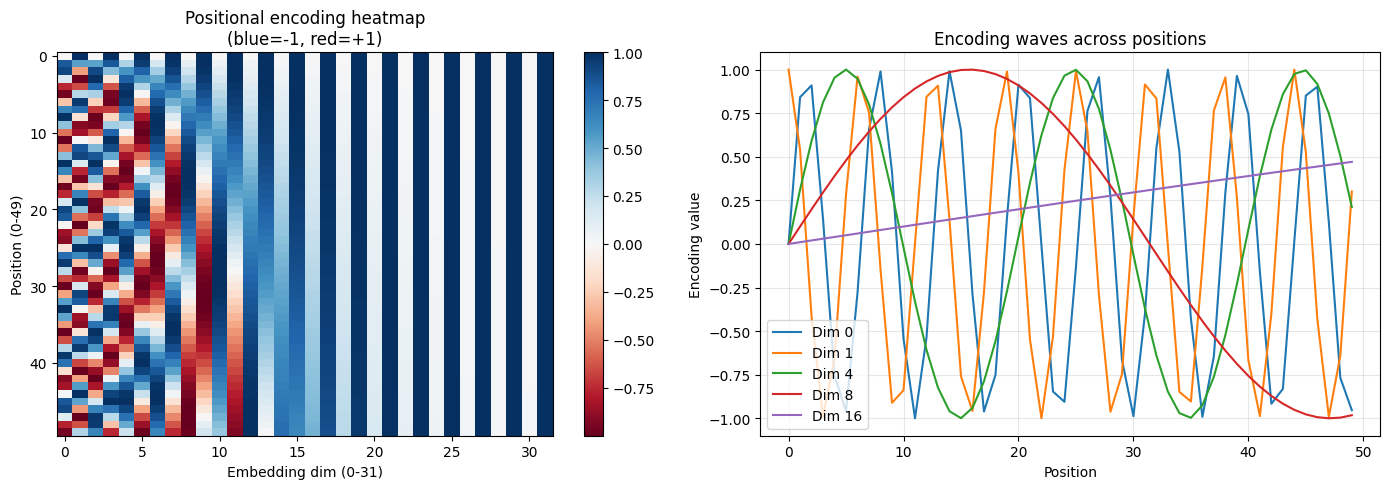

In [5]:
# Teaching note: follow this line to see the main step.
pe_viz = get_sinusoidal_encoding(seq_len=50, d_model=32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Teaching note: follow this line to see the main step.
im = axes[0].imshow(pe_viz.numpy(), aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Embedding dim (0-31)'); axes[0].set_ylabel('Position (0-49)')
axes[0].set_title('Positional encoding heatmap\n(blue=-1, red=+1)')
plt.colorbar(im, ax=axes[0])

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
for dim_idx in [0, 1, 4, 8, 16]:
    axes[1].plot(range(50), pe_viz[:, dim_idx].numpy(), label=f'Dim {dim_idx}')
axes[1].set_xlabel('Position'); axes[1].set_ylabel('Encoding value')
axes[1].set_title('Encoding waves across positions')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
[batch_size, seq_len]
```

Read the values printed above and connect them to the concept in this cell.
```
[batch_size, seq_len, embed_dim]
```

Read the values printed above and connect them to the concept in this cell.

In [6]:
class TokenEmbedding(nn.Module):
    'Read the values printed above and connect them to the concept in this cell.'
    
    def __init__(self, vocab_size, d_model, max_seq_len=512):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Teaching note: follow this line to see the main step.
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: [batch, seq_len] → output: [batch, seq_len, d_model]
        seq_len = x.shape[1]
        token_vecs = self.token_emb(x)         # Teaching note: follow this line to see the main step.
        pos_vecs = self.pe[:seq_len, :]        # Teaching note: follow this line to see the main step.
        return token_vecs + pos_vecs            # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
test_vocab_size, test_d_model = 20, 8
emb_module = TokenEmbedding(test_vocab_size, test_d_model)

dummy_input = torch.randint(0, test_vocab_size, (2, 5))
output = emb_module(dummy_input)

print(f"Read the values printed above and connect them to the concept in this cell.{dummy_input.shape}Read the values printed above and connect them to the concept in this cell.{output.shape}")
print(f"→ [batch=2, seq_len=5, d_model={test_d_model}]")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{output[0, 0, :3].tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{output[0, 3, :3].tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.→ [batch=2, seq_len=5, d_model=8]

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Reason
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

**Batch**

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
batch_size = 2

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.[[0, 1, 2],
 [5, 6, 8]]
```

Read the values printed above and connect them to the concept in this cell.

In [7]:
# Teaching note: follow this line to see the main step.
batch = torch.tensor([
    [0, 1, 2, 3, 0],  # the cat sat on the
    [1, 5, 4, 0, 0],  # cat dog mat the the (padding)
])

emb_output = emb_module(batch)
print(f"Read the values printed above and connect them to the concept in this cell.{batch.shape} = [batch_size=2, seq_len=5]")
print(f"Read the values printed above and connect them to the concept in this cell.{emb_output.shape} = [2, 5, d_model={test_d_model}]")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49258/3489069646.py:94: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49258/3489069646.py:94: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49258/3489069646.py:94: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49258/3489069646.py:94: UserWarning: Glyph 20171 (\N{CJK UNIFIED IDEOGRAPH-4ECB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49258/3489069646.py:94: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6

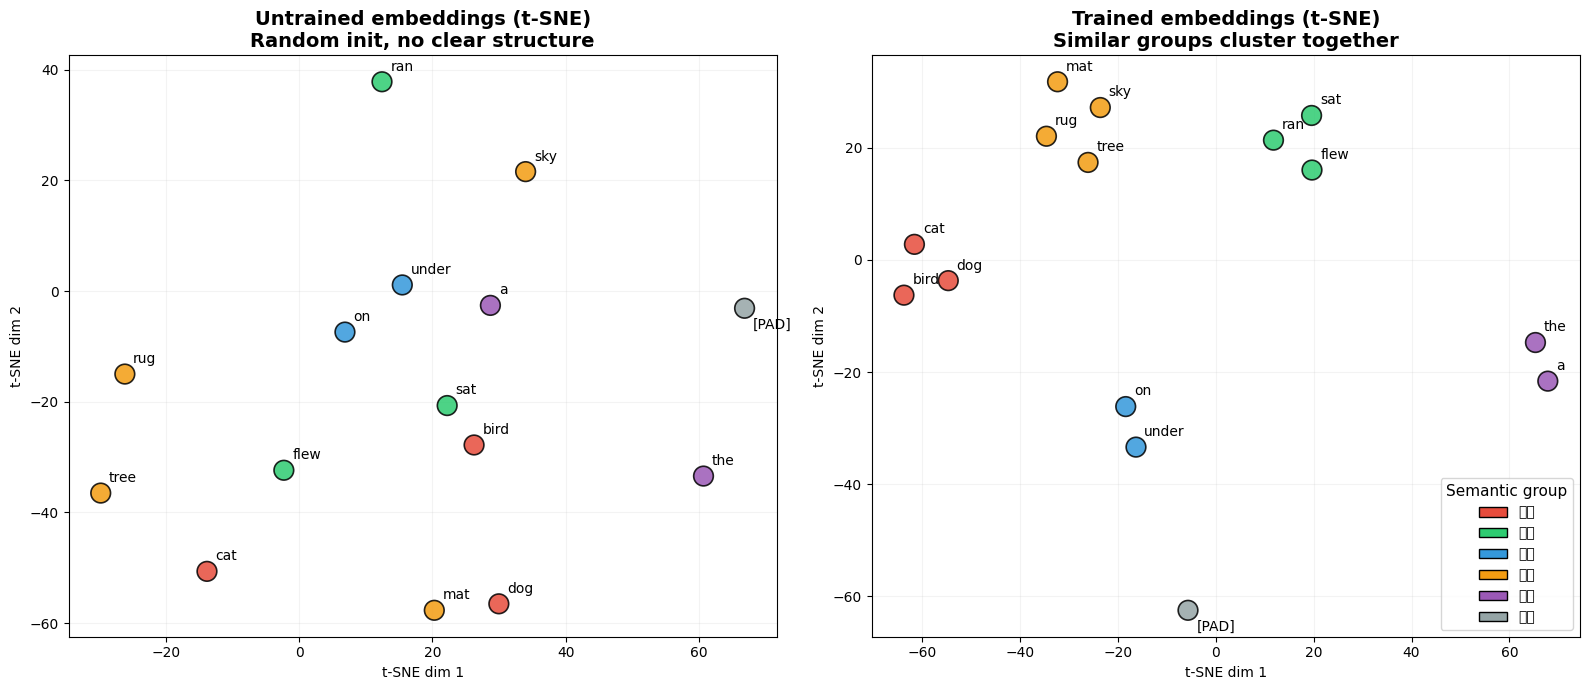

In [8]:
# Teaching note: follow this line to see the main step.
words = [
    "cat", "dog", "bird",          # Teaching note: follow this line to see the main step.
    "sat", "ran", "flew",          # Teaching note: follow this line to see the main step.
    "on", "under",                 # Teaching note: follow this line to see the main step.
    "mat", "rug", "tree", "sky",   # Teaching note: follow this line to see the main step.
    "the", "a",                    # Teaching note: follow this line to see the main step.
    "[PAD]",                       # Teaching note: follow this line to see the main step.
]
vocab_size = len(words)
d_model = 16

word_groups = {
    "cat": '"animal"', "dog": '"animal"', "bird": '"animal"',
    "sat": '"action"', "ran": '"action"', "flew": '"action"',
    "on": '"preposition"', "under": '"preposition"',
    "mat": '"object"', "rug": '"object"', "tree": '"object"', "sky": '"object"',
    "the": '"article"', "a": '"article"',
    "[PAD]": '"special"',
}

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
torch.manual_seed(42)
untrained_emb = nn.Embedding(vocab_size, d_model)

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
torch.manual_seed(999)
group_bases = {g: torch.randn(d_model) * 0.6
               for g in ['"animal"', '"action"', '"preposition"', '"object"', '"article"']}

trained_emb = nn.Embedding(vocab_size, d_model)
with torch.no_grad():
    for i, w in enumerate(words):
        group = word_groups[w]
        if group == '"special"':
            trained_emb.weight[i] = torch.tensor([10.0, 10.0] + [0.0] * (d_model - 2))
        else:
            trained_emb.weight[i] = group_bases[group] + 0.12 * torch.randn(d_model)

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
all_emb = torch.cat([untrained_emb.weight.data, trained_emb.weight.data], dim=0)

try:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    all_2d = tsne.fit_transform(all_emb.numpy())
except ImportError:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    all_2d = pca.fit_transform(all_emb.numpy())

n = vocab_size
untrained_2d = all_2d[:n]   # Teaching note: follow this line to see the main step.
trained_2d = all_2d[n:]     # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
group_colors = {
    '"animal"': "#e74c3c", '"action"': "#2ecc71", '"preposition"': "#3498db",
    '"object"': "#f39c12", '"article"': "#9b59b6", '"special"': "#95a5a6",
}
colors = [group_colors[word_groups[w]] for w in words]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Teaching note: follow this line to see the main step.
axes[0].scatter(untrained_2d[:, 0], untrained_2d[:, 1], c=colors, s=200,
                edgecolors='black', linewidth=1.2, alpha=0.85, zorder=5)
for i, w in enumerate(words):
    axes[0].annotate(w, (untrained_2d[i, 0], untrained_2d[i, 1]),
                     fontsize=10, textcoords="offset points", xytext=(6, 8 if w != "[PAD]" else -15))
axes[0].set_title("Untrained embeddings (t-SNE)\nRandom init, no clear structure", fontsize=14, fontweight='bold')
axes[0].set_xlabel("t-SNE dim 1"); axes[0].set_ylabel("t-SNE dim 2")
axes[0].grid(True, alpha=0.15)

# Teaching note: follow this line to see the main step.
axes[1].scatter(trained_2d[:, 0], trained_2d[:, 1], c=colors, s=200,
                edgecolors='black', linewidth=1.2, alpha=0.85, zorder=5)
for i, w in enumerate(words):
    axes[1].annotate(w, (trained_2d[i, 0], trained_2d[i, 1]),
                     fontsize=10, textcoords="offset points", xytext=(6, 8 if w != "[PAD]" else -15))
axes[1].set_title("Trained embeddings (t-SNE)\nSimilar groups cluster together", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE dim 1"); axes[1].set_ylabel("t-SNE dim 2")
axes[1].grid(True, alpha=0.15)

from matplotlib.patches import Patch
axes[1].legend(
    handles=[Patch(facecolor=c, edgecolor='black', label=g) for g, c in group_colors.items()],
    loc='lower right', fontsize=10, title="Semantic group", title_fontsize=11)

plt.tight_layout()
plt.show()

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.


---

## Summary
Read the values printed above and connect them to the concept in this cell.
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.5. Read the values printed above and connect them to the concept in this cell.6. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

---

## Read the values printed above and connect them to the concept in this cell.
These 3 exercises fall into two groups:
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.
> Explanation: the printed values show the main mechanism in this step.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [ ]:
# Teaching note: follow this line to see the main step.
import torch

embedding_table = torch.tensor([
    [1.0, 0.0],  # token 0
    [0.0, 1.0],  # token 1
    [1.0, 1.0],  # token 2
])
token_ids = torch.tensor([2, 0, 1])

# Teaching note: follow this line to see the main step.
vectors = 'TODO: replace this placeholder with your code'

assert not isinstance(vectors, str), 'Please replace the placeholder before running the assertion.'
expected = torch.tensor([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
assert torch.equal(vectors, expected), vectors
print('Exercise passed: you have understood this step.')

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [ ]:
# Teaching note: follow this line to see the main step.
token_vectors = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0],
])
position_vectors = torch.tensor([
    [0.0, 0.1],
    [0.2, 0.3],
])

# Teaching note: follow this line to see the main step.
final_vectors = 'TODO: replace this placeholder with your code'

assert not isinstance(final_vectors, str), 'Please replace the placeholder before running the assertion.'
expected = torch.tensor([[1.0, 1.1], [1.2, 1.3]])
assert torch.allclose(final_vectors, expected), final_vectors
assert not torch.allclose(final_vectors[0], final_vectors[1])
print('Exercise passed: you have understood this step.')

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [ ]:
# Teaching note: follow this line to see the main step.
embeddings = torch.tensor([
    [[1.0, 1.0], [2.0, 2.0], [9.0, 9.0], [9.0, 9.0]],
])
attention_mask = torch.tensor([[1, 1, 0, 0]])

# Teaching note: follow this line to see the main step.
masked_embeddings = 'TODO: replace this placeholder with your code'

assert not isinstance(masked_embeddings, str), 'Please replace the placeholder before running the assertion.'
expected = torch.tensor([[[1.0, 1.0], [2.0, 2.0], [0.0, 0.0], [0.0, 0.0]]])
assert torch.equal(masked_embeddings, expected), masked_embeddings
print('Exercise passed: you have understood this step.')